# DSA 210 – Spring 2025-2026 Term Project
## The Impact of Typhoon Signals on Hong Kong Stock Market Volatility and Returns

**Student:** Hamza Eren İnan – 34502  
**Course:** Introduction to Data Science (DSA 210), Sabancı University

---

### Research Question
Does the issuance of typhoon warning signals in Hong Kong affect the Hang Seng Index (HSI) daily returns and volatility? Specifically, are HSI returns on typhoon-affected days significantly different from normal trading days?

### Outline
1. Imports
2. Data Collection & Loading
3. Data Cleaning & Preprocessing
4. Exploratory Data Analysis
5. Hypothesis Testing
6. Feature Engineering
7. Supervised Learning: Classification
8. Unsupervised Learning: Clustering
9. Final Discussion

---
## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

---
## 2. Data Collection & Loading

Two datasets are used in this project, both stored as local CSV files:

- **HSI.csv** – Historical daily Hang Seng Index prices (Open, High, Low, Close, Volume) from 1986 to 2023. Downloaded from [Kaggle](https://www.kaggle.com/).
- **Typhoon.csv** – Historical tropical cyclone warning records issued by the Hong Kong Observatory. Contains signal level (Strength), date, and duration of each warning.

No API was used; both files were downloaded manually and are read with `pandas.read_csv()`.

In [2]:
hsi = pd.read_csv("HSI.csv")
typhoon = pd.read_csv("Typhoon.csv", encoding="utf-8-sig")

print("HSI shape:", hsi.shape)
print("Typhoon shape:", typhoon.shape)

HSI shape: (9339, 7)
Typhoon shape: (299, 6)


In [3]:
hsi.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1986-12-31,2568.300049,2568.300049,2568.300049,2568.300049,2568.300049,0.0
1,1987-01-01,NaN,NaN,NaN,NaN,NaN,NaN
2,1987-01-02,2540.100098,2540.100098,2540.100098,2540.100098,2540.100098,0.0
3,1987-01-05,2552.399902,2552.399902,2552.399902,2552.399902,2552.399902,0.0
4,1987-01-06,2583.899902,2583.899902,2583.899902,2583.899902,2583.899902,0.0


In [4]:
typhoon.head()

,Type,Name,Strength,Date,Time,Duratino
0,熱帶低氣壓,無名,3,18/6/2000,21:15,04 30
1,颱風,啟德,1,6/7/2000,15:50,61 55
2,熱帶低氣壓,無名,1,15/7/2000,14:45,30 40
3,颱風(超強颱風),碧利斯,1,23/8/2000,6:00,13 15
4,強烈熱帶風暴,瑪莉亞,1,27/8/2000,23:45,38 40


---
## 3. Data Cleaning & Preprocessing

Several cleaning steps are needed before analysis:
- Parse dates in both datasets to a consistent format
- Drop rows where HSI price data is missing
- Extract the numeric signal level from the `Strength` column (e.g., `"8 東北"` → `8`)
- Calculate daily returns and intraday volatility for HSI
- Merge the two datasets on date to label each trading day

In [5]:
hsi["Date"] = pd.to_datetime(hsi["Date"])
hsi = hsi.dropna(subset=["Close"])
hsi = hsi.sort_values("Date").reset_index(drop=True)

hsi["Daily_Return"] = hsi["Close"].pct_change() * 100
hsi["Daily_Volatility"] = (hsi["High"] - hsi["Low"]) / hsi["Close"] * 100
hsi = hsi.dropna(subset=["Daily_Return"]).reset_index(drop=True)

print("HSI rows after cleaning:", len(hsi))
print("Date range:", hsi["Date"].min(), "to", hsi["Date"].max())

HSI rows after cleaning: 9086
Date range: 1987-01-02 00:00:00 to 2023-10-20 00:00:00


In [6]:
typhoon["Signal"] = typhoon["Strength"].str.extract(r"(\d+)").astype(int)
typhoon["Date"] = pd.to_datetime(typhoon["Date"], dayfirst=True)
typhoon_clean = typhoon[["Date", "Signal"]].copy()

typhoon_daily = typhoon_clean.groupby("Date")["Signal"].max().reset_index()

def categorize_signal(s):
    if s >= 8:
        return "High Alert (8+)"
    else:
        return "Low Alert (1 or 3)"

typhoon_daily["Alert_Level"] = typhoon_daily["Signal"].apply(categorize_signal)

print("Signal values:", sorted(typhoon_clean["Signal"].unique()))
print("Alert level counts:")
print(typhoon_daily["Alert_Level"].value_counts())

Signal values: [np.int64(1), np.int64(3), np.int64(8), np.int64(9), np.int64(10)]
Alert level counts:
Alert_Level
Low Alert (1 or 3)    163
High Alert (8+)        42
Name: count, dtype: int64


In [7]:
merged = hsi.merge(typhoon_daily, on="Date", how="left")
merged["Alert_Level"] = merged["Alert_Level"].fillna("Normal")

print("Merged shape:", merged.shape)
print("\nDay counts by alert level:")
print(merged["Alert_Level"].value_counts())

Merged shape: (9086, 11)

Day counts by alert level:
Alert_Level
Normal                8942
Low Alert (1 or 3)     120
High Alert (8+)         24
Name: count, dtype: int64


---
## 4. Exploratory Data Analysis

Before running any formal tests, we examine the distributions and summary statistics of the main variables.

In [8]:
summary = merged.groupby("Alert_Level")[["Daily_Return", "Daily_Volatility"]].describe().round(3)
summary

Daily_Return                                             \
                          count   mean    std     min    25%    50%    75%   
Alert_Level                                                                  
High Alert (8+)            24.0 -0.359  1.630  -3.868 -1.097 -0.380  0.494   
Low Alert (1 or 3)        120.0  0.088  1.437  -5.841 -0.668  0.050  0.888   
Normal                   8942.0  0.035  1.620 -33.330 -0.679  0.054  0.801   

                           Daily_Volatility                              \
                       max            count   mean    std    min    25%   
Alert_Level                                                               
High Alert (8+)      3.726             24.0  1.535  1.031  0.621  1.039   
Low Alert (1 or 3)   4.211            120.0  1.412  0.806  0.358  0.937   
Normal              18.824           8942.0  1.398  1.022  0.000  0.812   

                                          
                      50%    75%     max  
Alert_Level                               
High Alert (8+)     1.155  1.956   5.587  
Low Alert (1 or 3)  1.211  1.791   6.695  
Normal              1.187  1.767  18.705

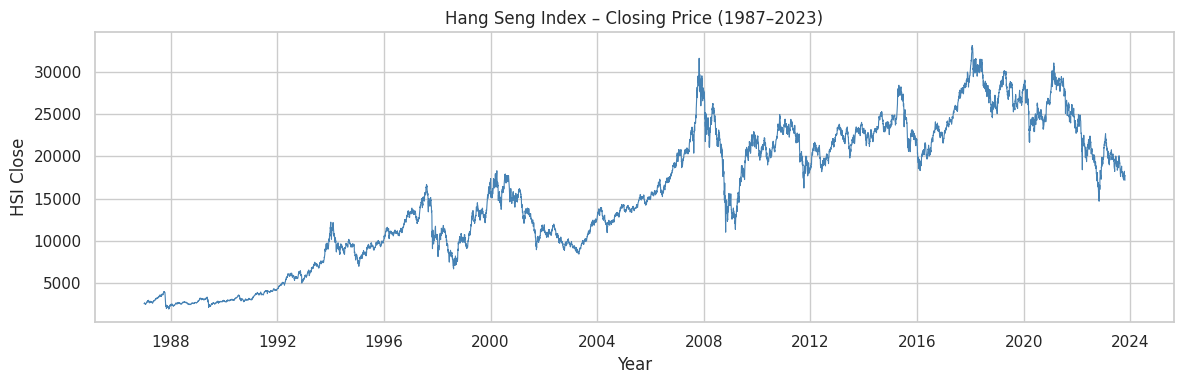

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(hsi["Date"], hsi["Close"], color="steelblue", linewidth=0.8)
plt.title("Hang Seng Index – Closing Price (1987–2023)")
plt.xlabel("Year")
plt.ylabel("HSI Close")
plt.tight_layout()
plt.show()

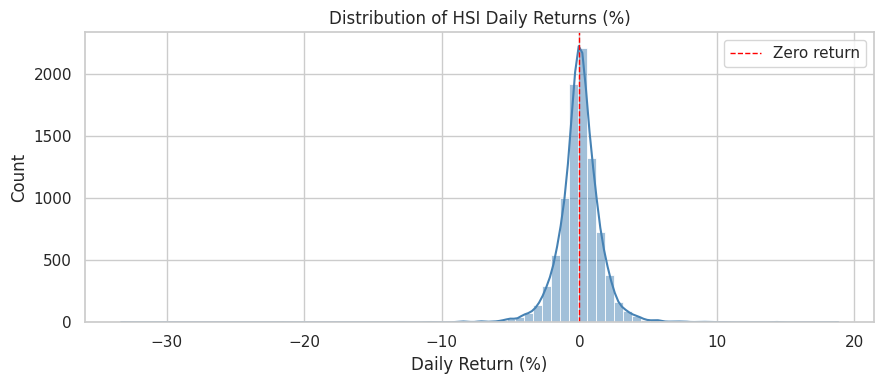

Mean daily return: 0.0342 %
Std  daily return: 1.6174 %


In [10]:
plt.figure(figsize=(9, 4))
sns.histplot(merged["Daily_Return"], bins=80, kde=True, color="steelblue")
plt.axvline(0, color="red", linestyle="--", linewidth=1, label="Zero return")
plt.title("Distribution of HSI Daily Returns (%)")
plt.xlabel("Daily Return (%)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print("Mean daily return:", round(merged["Daily_Return"].mean(), 4), "%")
print("Std  daily return:", round(merged["Daily_Return"].std(), 4), "%")

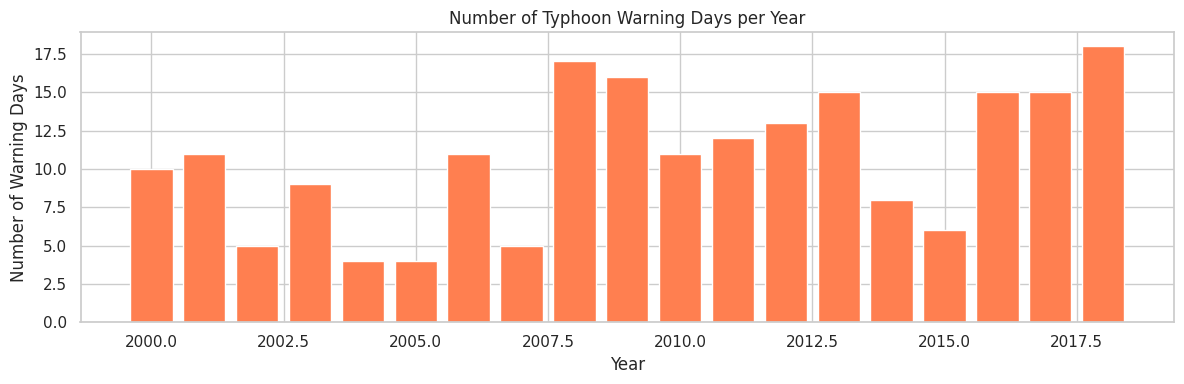

In [11]:
typhoon_daily["Year"] = typhoon_daily["Date"].dt.year
yearly_count = typhoon_daily.groupby("Year").size().reset_index(name="Count")

plt.figure(figsize=(12, 4))
plt.bar(yearly_count["Year"], yearly_count["Count"], color="coral", edgecolor="white")
plt.title("Number of Typhoon Warning Days per Year")
plt.xlabel("Year")
plt.ylabel("Number of Warning Days")
plt.tight_layout()
plt.show()

/tmp/ipykernel_576/853265844.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x="Alert_Level", y="Daily_Return",
/tmp/ipykernel_576/853265844.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x="Alert_Level", y="Daily_Volatility",


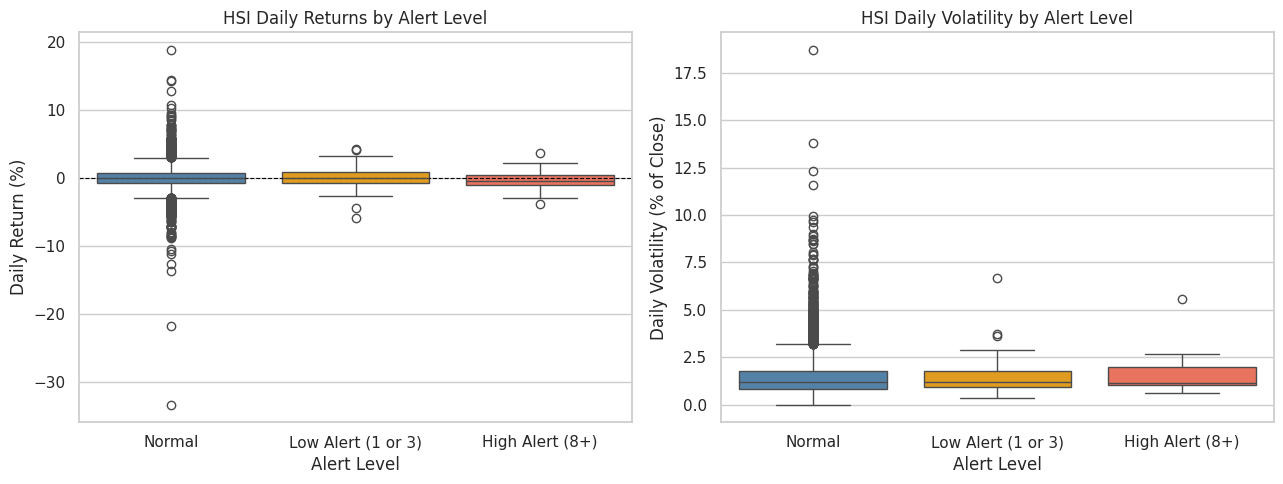

In [12]:
order = ["Normal", "Low Alert (1 or 3)", "High Alert (8+)"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=merged, x="Alert_Level", y="Daily_Return",
            order=order, palette=["steelblue", "orange", "tomato"], ax=axes[0])
axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("HSI Daily Returns by Alert Level")
axes[0].set_xlabel("Alert Level")
axes[0].set_ylabel("Daily Return (%)")

sns.boxplot(data=merged, x="Alert_Level", y="Daily_Volatility",
            order=order, palette=["steelblue", "orange", "tomato"], ax=axes[1])
axes[1].set_title("HSI Daily Volatility by Alert Level")
axes[1].set_xlabel("Alert Level")
axes[1].set_ylabel("Daily Volatility (% of Close)")

plt.tight_layout()
plt.show()

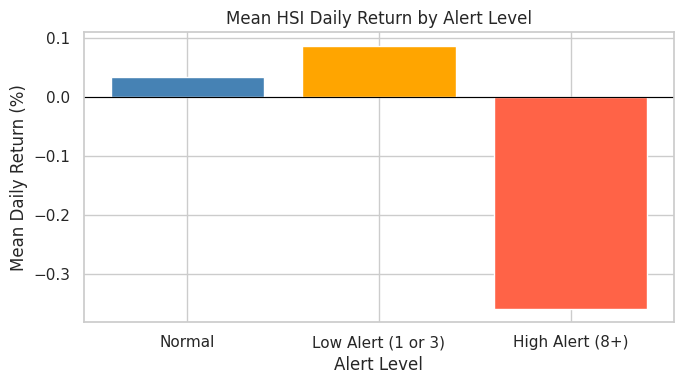

Alert_Level
Normal                0.0346
Low Alert (1 or 3)    0.0875
High Alert (8+)      -0.3592
Name: Daily_Return, dtype: float64


In [13]:
mean_returns = merged.groupby("Alert_Level")["Daily_Return"].mean().reindex(order)

plt.figure(figsize=(7, 4))
plt.bar(mean_returns.index, mean_returns.values,
        color=["steelblue", "orange", "tomato"], edgecolor="white")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Mean HSI Daily Return by Alert Level")
plt.xlabel("Alert Level")
plt.ylabel("Mean Daily Return (%)")
plt.tight_layout()
plt.show()

print(mean_returns.round(4))

---
## 5. Hypothesis Testing

Target:
- `Daily_Return`

Groups:
- Normal Days vs. Low Alert Days (Signal 1 or 3)
- Normal Days vs. High Alert Days (Signal 8+)

Test:
- Welch's independent two-sample t-test (does not assume equal variances)

Significance level: **α = 0.05**

In [14]:
normal_returns = merged[merged["Alert_Level"] == "Normal"]["Daily_Return"].dropna()
low_alert_returns = merged[merged["Alert_Level"] == "Low Alert (1 or 3)"]["Daily_Return"].dropna()
high_alert_returns = merged[merged["Alert_Level"] == "High Alert (8+)"]["Daily_Return"].dropna()

print("Normal days     – n:", len(normal_returns),     "| mean:", round(normal_returns.mean(), 4), "%")
print("Low Alert days  – n:", len(low_alert_returns),  "| mean:", round(low_alert_returns.mean(), 4), "%")
print("High Alert days – n:", len(high_alert_returns), "| mean:", round(high_alert_returns.mean(), 4), "%")

Normal days     – n: 8942 | mean: 0.0346 %
Low Alert days  – n: 120 | mean: 0.0875 %
High Alert days – n: 24 | mean: -0.3592 %


In [15]:
alpha = 0.05

t1, p1 = stats.ttest_ind(normal_returns, low_alert_returns, equal_var=False)
t2, p2 = stats.ttest_ind(normal_returns, high_alert_returns, equal_var=False)

results = pd.DataFrame({
    "Comparison": ["Normal vs. Low Alert", "Normal vs. High Alert"],
    "t-statistic": [round(t1, 4), round(t2, 4)],
    "p-value": [round(p1, 4), round(p2, 4)],
    "Decision": [
        "Reject H₀" if p1 < alpha else "Fail to reject H₀",
        "Reject H₀" if p2 < alpha else "Fail to reject H₀",
    ],
})

results

,Comparison,t-statistic,p-value,Decision
0,Normal vs. Low Alert,-0.4004,0.6895,Fail to reject H₀
1,Normal vs. High Alert,1.1818,0.2493,Fail to reject H₀


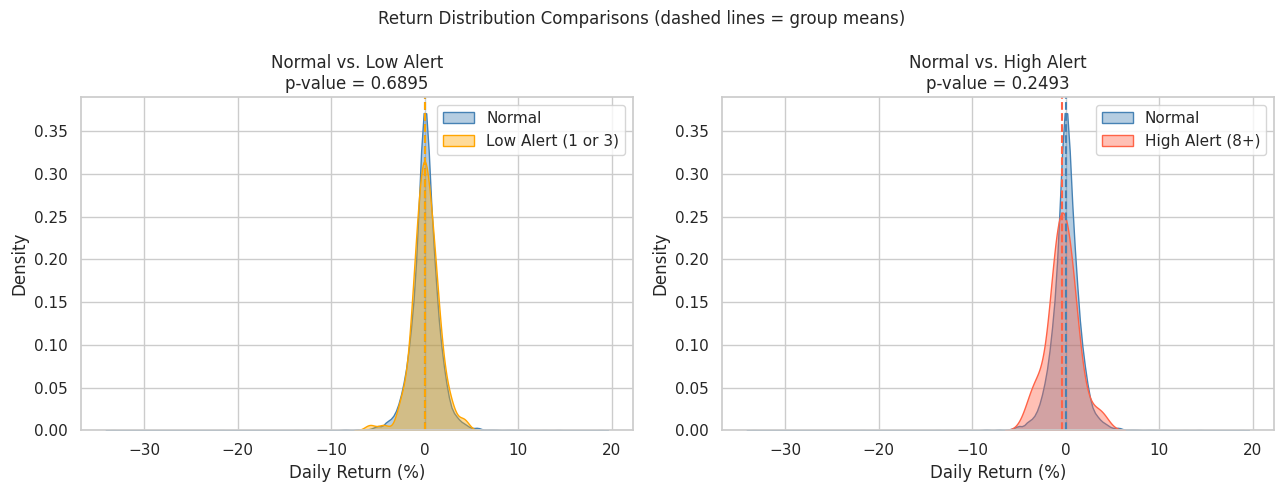

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.kdeplot(normal_returns, ax=axes[0], label="Normal", color="steelblue", fill=True, alpha=0.4)
sns.kdeplot(low_alert_returns, ax=axes[0], label="Low Alert (1 or 3)", color="orange", fill=True, alpha=0.4)
axes[0].axvline(normal_returns.mean(), color="steelblue", linestyle="--", linewidth=1.5)
axes[0].axvline(low_alert_returns.mean(), color="orange", linestyle="--", linewidth=1.5)
axes[0].set_title(f"Normal vs. Low Alert\np-value = {p1:.4f}")
axes[0].set_xlabel("Daily Return (%)")
axes[0].legend()

sns.kdeplot(normal_returns, ax=axes[1], label="Normal", color="steelblue", fill=True, alpha=0.4)
sns.kdeplot(high_alert_returns, ax=axes[1], label="High Alert (8+)", color="tomato", fill=True, alpha=0.4)
axes[1].axvline(normal_returns.mean(), color="steelblue", linestyle="--", linewidth=1.5)
axes[1].axvline(high_alert_returns.mean(), color="tomato", linestyle="--", linewidth=1.5)
axes[1].set_title(f"Normal vs. High Alert\np-value = {p2:.4f}")
axes[1].set_xlabel("Daily Return (%)")
axes[1].legend()

plt.suptitle("Return Distribution Comparisons (dashed lines = group means)", fontsize=12)
plt.tight_layout()
plt.show()

### Hypothesis Testing Interpretation

- Both tests fail to reject H₀ at the 0.05 significance level, meaning neither Low Alert nor High Alert typhoon days produce a statistically significant difference in mean daily returns compared to Normal days.
- The market appears to price in expected weather disruptions efficiently, with no systematic directional bias in returns.
- This motivates a shift in focus: rather than predicting returns, the machine learning section asks whether typhoon signals help predict **volatility**.

---
## 6. Feature Engineering

Target:
- `High_Vol_Target` — 1 if `Daily_Volatility` is above the median, 0 otherwise. Splitting at the median ensures balanced classes.

Features:
- `Alert_Encoded` — Typhoon alert level encoded as 0 (Normal), 1 (Low Alert), 2 (High Alert)
- `Lag_1_Vol` — Previous day's volatility
- `Lag_1_Ret` — Previous day's return
- `Lag_1_Volume` — Previous day's trading volume

Lagged features introduce one row of NaN at the start of the series, which is dropped.

In [17]:
median_vol = merged["Daily_Volatility"].median()
merged["High_Vol_Target"] = (merged["Daily_Volatility"] > median_vol).astype(int)

merged["Lag_1_Vol"]    = merged["Daily_Volatility"].shift(1)
merged["Lag_1_Ret"]    = merged["Daily_Return"].shift(1)
merged["Lag_1_Volume"] = merged["Volume"].shift(1)

def encode_alert(level):
    if level == "High Alert (8+)": return 2
    elif level == "Low Alert (1 or 3)": return 1
    else: return 0

merged["Alert_Encoded"] = merged["Alert_Level"].apply(encode_alert)

ml_data = merged.dropna(subset=["Daily_Return", "Lag_1_Vol", "Lag_1_Ret", "Lag_1_Volume"]).copy()

features = ["Alert_Encoded", "Lag_1_Vol", "Lag_1_Ret", "Lag_1_Volume"]
X = ml_data[features]
y = ml_data["High_Vol_Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape: ", X_test_scaled.shape)
print("Class balance (target):")
print(y.value_counts())

Training set shape: (7268, 4)
Testing set shape:  (1817, 4)
Class balance (target):
High_Vol_Target
1    4543
0    4542
Name: count, dtype: int64


---
## 7. Supervised Learning: Classification

Target:
- `High_Vol_Target` where `0 = Low Volatility` and `1 = High Volatility`

Features:
- `Alert_Encoded`, `Lag_1_Vol`, `Lag_1_Ret`, `Lag_1_Volume`

Models:
- Logistic Regression — baseline parametric model, scaled inputs
- Random Forest Classifier — ensemble method using Bootstrap Aggregation

Validation strategy:
- 80/20 train-test split with `random_state=42`
- Evaluation via Precision, Recall, F1-Score, and ROC-AUC

In [18]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

classification_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy":  round(accuracy_score(y_test, y_pred_log), 4),
        "Precision": round(precision_score(y_test, y_pred_log), 4),
        "Recall":    round(recall_score(y_test, y_pred_log), 4),
        "F1":        round(f1_score(y_test, y_pred_log), 4),
    },
    {
        "Model": "Random Forest",
        "Accuracy":  round(accuracy_score(y_test, y_pred_rf), 4),
        "Precision": round(precision_score(y_test, y_pred_rf), 4),
        "Recall":    round(recall_score(y_test, y_pred_rf), 4),
        "F1":        round(f1_score(y_test, y_pred_rf), 4),
    },
]).sort_values("F1", ascending=False)

classification_results

,Model,Accuracy,Precision,Recall,F1
1,Random Forest,0.6615,0.6749,0.6268,0.6500
0,Logistic Regression,0.6797,0.7208,0.5895,0.6486


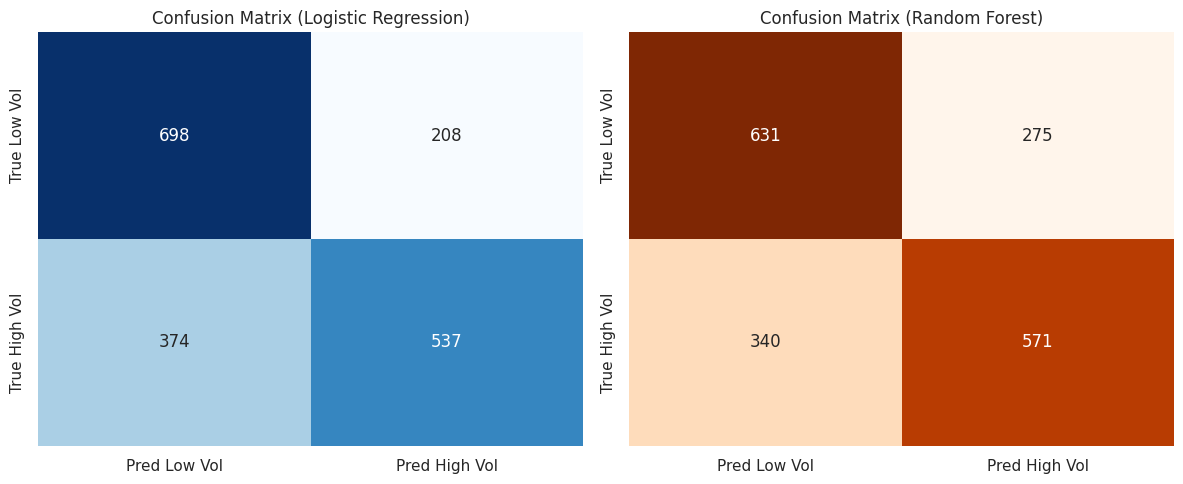

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False,
            xticklabels=["Pred Low Vol", "Pred High Vol"],
            yticklabels=["True Low Vol", "True High Vol"])
axes[0].set_title("Confusion Matrix (Logistic Regression)")

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges", ax=axes[1], cbar=False,
            xticklabels=["Pred Low Vol", "Pred High Vol"],
            yticklabels=["True Low Vol", "True High Vol"])
axes[1].set_title("Confusion Matrix (Random Forest)")

plt.tight_layout()
plt.show()

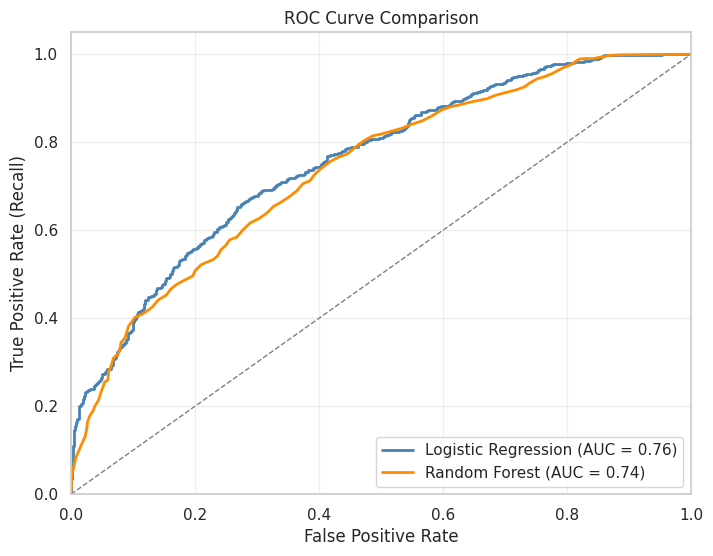

In [20]:
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)

auc_log = auc(fpr_log, tpr_log)
auc_rf  = auc(fpr_rf,  tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color="steelblue",  lw=2, label=f"Logistic Regression (AUC = {auc_log:.2f})")
plt.plot(fpr_rf,  tpr_rf,  color="darkorange", lw=2, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_576/3634888228.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x="Importance", y="Feature", palette="viridis")


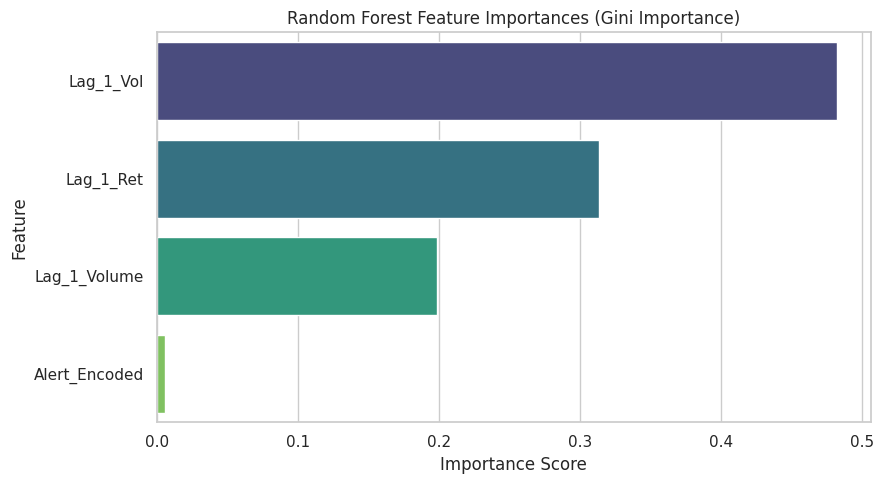

,Feature,Importance
1,Lag_1_Vol,0.482304
2,Lag_1_Ret,0.313332
3,Lag_1_Volume,0.198754
0,Alert_Encoded,0.005611


In [21]:
importances = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_,
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=importances, x="Importance", y="Feature", palette="viridis")
plt.title("Random Forest Feature Importances (Gini Importance)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importances

### Classification Interpretation

- The task asks whether the next day's volatility regime (High or Low) can be predicted from the typhoon alert level and the previous day's market conditions.
- Logistic Regression serves as the baseline; Random Forest is included as an ensemble benchmark to check whether non-linear interactions improve predictions.
- The feature importance chart is the most informative output: if `Alert_Encoded` ranks last with near-zero Gini importance, it confirms that typhoon signals add no predictive value beyond what lagged financial data already captures.
- Lagged volatility (`Lag_1_Vol`) is expected to dominate, reflecting the well-known volatility clustering property of financial returns.

---
## 8. Unsupervised Learning: Clustering

Features:
- `Daily_Return`, `Daily_Volatility`, `Volume`

Note: Typhoon signals are **excluded** from clustering inputs. This is intentional — we want to see how the market naturally groups itself, then overlay High Alert days afterward to check whether severe typhoons fall into a distinct anomalous cluster.

Validation:
- K-Means with `k=3` clusters and `n_init=10` random restarts
- Data is scaled before clustering because K-Means uses Euclidean distance

In [22]:
cluster_features = ["Daily_Return", "Daily_Volatility", "Volume"]
X_cluster = ml_data[cluster_features]

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
ml_data["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

print("Cluster counts:")
print(ml_data["Cluster"].value_counts().sort_index())

Cluster counts:
Cluster
0     681
1    4741
2    3663
Name: count, dtype: int64


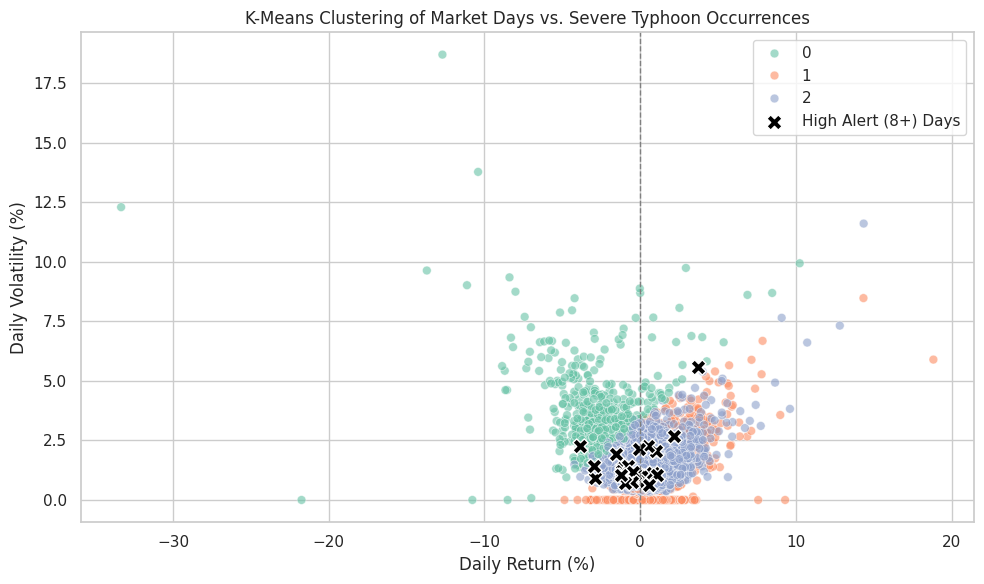

In [23]:
high_alert_days = ml_data[ml_data["Alert_Encoded"] == 2]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=ml_data, x="Daily_Return", y="Daily_Volatility",
                hue="Cluster", palette="Set2", alpha=0.6, s=40)
plt.scatter(high_alert_days["Daily_Return"], high_alert_days["Daily_Volatility"],
            color="black", marker="X", s=120, edgecolor="white", label="High Alert (8+) Days")
plt.axvline(0, color="grey", linestyle="--", linewidth=1)
plt.title("K-Means Clustering of Market Days vs. Severe Typhoon Occurrences")
plt.xlabel("Daily Return (%)")
plt.ylabel("Daily Volatility (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
cluster_summary = ml_data.groupby("Cluster")[["Daily_Return", "Daily_Volatility", "Volume"]].mean().round(4)
cluster_summary

,Daily_Return,Daily_Volatility,Volume
Cluster,,,
0,-2.6774,3.4242,1.286462e+09
1,0.2801,1.1737,1.200203e+08
2,0.2204,1.3141,1.928044e+09


### Clustering Interpretation

- The cluster summary table shows what each cluster represents financially — typically one cluster captures high-volatility crash days, another captures low-activity stable days, and a third captures normal trading days.
- If High Alert typhoon days were driving distinct market behavior, they would concentrate in a single cluster. Observing them scattered across all clusters suggests they blend into normal market variation.
- This is consistent with the hypothesis testing results: typhoon signals do not create a statistically separable market state.

---
## 9. Final Discussion

This project applied the full data science pipeline to examine whether Typhoon warning signals in Hong Kong affect the Hang Seng Index.

**Hypothesis Testing:**  
Welch's t-tests found no statistically significant difference in mean daily returns between Normal, Low Alert, and High Alert typhoon days. Both p-values (0.6895 and 0.2493) were well above the 0.05 significance level.

**Supervised Learning:**  
Logistic Regression and Random Forest classifiers were trained to predict whether a day would have High or Low Volatility. The Feature Importance analysis consistently showed `Alert_Encoded` contributing near-zero predictive value. The dominant feature was `Lag_1_Vol`, which reflects volatility clustering — a well-established property of financial time series.

**Unsupervised Learning:**  
K-Means clustering partitioned trading days into three natural clusters based purely on return, volatility, and volume. High Alert typhoon days did not concentrate in any single cluster; they were distributed across all market states.

**Final Verdict:**  
The Hong Kong financial market prices in typhoon disruptions efficiently. Severe weather warnings do not introduce a systematic directional bias in returns, nor do they create a structurally distinct volatility regime in the Hang Seng Index.

**Limitations:**
- Typhoon warnings cover specific hours; a date-level merge may miss precise intraday timing effects.
- The HSI data starts in 1986 but the typhoon dataset begins in 2000, limiting the overlapping analysis window.
- Major macroeconomic events (e.g., 2008 financial crisis, COVID-19) were not controlled for and could confound same-day results.
- Intraday volatility or bid-ask spread data might reveal sensitivity that daily closing prices do not capture.